# Assom reproduction: dual branch comparison (tf_specs vs AE latent)

This notebook builds two comparable branches and evaluates both with the same criteria:

1. Dynamic sub-segmentation + mel/tf-spec extraction
2. Top-5 emitter model selection with:
   - Silhouette (internal validation)
   - ARI/NMI against DTW-MFCC proxy labels
3. UMAP + HDBSCAN full-data fit for each branch
4. Visual comparison and downstream syntax tests

Branches:
- **Branch A**: `tf_specs` (flattened)
- **Branch B**: `AE latent` (autoencoder embedding -> UMAP/HDBSCAN)


## 1) Config


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_ROOT = '/Volumes/T7/data'
DATA_DIR = Path(DATA_ROOT) if DATA_ROOT else (PROJECT_ROOT / 'data')
RAW_DIR = DATA_DIR / 'raw' / 'fruitbat'
RAW_DIR.mkdir(parents=True, exist_ok=True)

MAX_FILES = None
MAX_SEGMENTS = None
WAV_LOAD_TIMEOUT_SEC = 90
BATCH_SIZE_SEGMENTS = 25_000

USE_DYNAMIC_SUBSEG = True
SEG_N_FFT = 1024
SEG_HOP_LENGTH_MS = 0.5
SEG_WIN_LENGTH_MS = 4
SEG_REF_LEVEL_DB = 20
SEG_PRE = 0.97
SEG_MIN_LEVEL_DB = -30
SEG_SILENCE_THRESHOLD = 0.1
SEG_MIN_SYLLABLE_LENGTH_S = 0.01
SEG_SPECTRAL_RANGE = [5000, 60000]
SEG_MIN_LEVEL_DB_FLOOR = 20

SR = 250_000
N_FFT = 1024
HOP_LENGTH = 512
N_MELS = 32
PAD_LEN = 128
FMIN, FMAX = 500, 120_000

UMAP_CANDIDATES = [
    (30, 0.3, 'euclidean'),
    (30, 0.0, 'euclidean'),
    (15, 0.0, 'euclidean'),
]
HDBSCAN_FRAC_CANDIDATES = [0.02, 0.015, 0.01, 0.005]
HDBSCAN_MIN_SAMPLES = 20
HDBSCAN_EPS = 0.1
HDBSCAN_METHOD = 'leaf'

TOP_EMITTERS = 5
MODELSEL_MAX_PER_EMITTER = 3000
PROXY_MAX_PER_EMITTER = 60

RUN_AE_BRANCH = True
AE_TRAIN_MAX_SAMPLES = 40_000
AE_EPOCHS = 20
AE_BATCH_SIZE = 256
AE_LATENT_DIM = 64

EXCLUDE_CONTEXTS = {0, 11, 12}
MIN_SAMPLES_PER_CONTEXT = 30
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CONTEXT_NAMES = {
    1: 'Separation', 2: 'Biting', 3: 'Feeding', 4: 'Fighting',
    5: 'Grooming', 6: 'Isolation', 7: 'Kissing', 8: 'Landing',
    9: 'Mating protest', 10: 'Threat-like',
}

print('RAW_DIR:', RAW_DIR)
print('MAX_FILES:', MAX_FILES or 'all', '| MAX_SEGMENTS:', MAX_SEGMENTS or 'no cap')
print('Dynamic sub-segmentation:', USE_DYNAMIC_SUBSEG)
print('Run AE branch:', RUN_AE_BRANCH)


RAW_DIR: /Volumes/T7/data/raw/fruitbat
MAX_FILES: all | MAX_SEGMENTS: no cap
Dynamic sub-segmentation: True
Run AE branch: True


## 2) Load metadata


In [2]:
annotations = pd.read_csv(RAW_DIR / 'Annotations.csv')
annotations = annotations.astype({
    'FileID': int,
    'Emitter': int,
    'Addressee': int,
    'Context': int,
    'Start sample': int,
    'End sample': int,
})
annotations = annotations[~annotations['Context'].isin(EXCLUDE_CONTEXTS)].copy()

with open(RAW_DIR / 'FileInfo.csv', 'r') as f:
    max_cols = max(len(line.split(',')) for line in f)

file_info = pd.read_csv(RAW_DIR / 'FileInfo.csv', header=None, names=range(max_cols), low_memory=False)
file_info = file_info.iloc[1:][[0, 2, 3]].copy()
file_info.columns = ['FileID', 'FileName', 'FileFolder']
file_info['FileID'] = file_info['FileID'].astype(int)
file_info = file_info.set_index('FileID')

wav_root = RAW_DIR / 'zip_contents'
file_info['wav_path'] = file_info.apply(
    lambda r: str(wav_root / str(r['FileFolder']).strip() / str(r['FileName']).strip()), axis=1
)

print('Annotations:', len(annotations))
print('FileInfo:', len(file_info))
print('Contexts:', sorted(annotations['Context'].unique().tolist()))


Annotations: 26816
FileInfo: 293238
Contexts: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## 3) Dynamic sub-segmentation + tf_specs extraction (batched)


In [3]:
import librosa
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FuturesTimeoutError
from tqdm.auto import tqdm

try:
    from vocalseg.dynamic_thresholding import dynamic_threshold_segmentation
    HAS_VOCALSEG = True
except Exception:
    HAS_VOCALSEG = False

print('vocalseg available:', HAS_VOCALSEG)
if USE_DYNAMIC_SUBSEG and not HAS_VOCALSEG:
    print('WARNING: dynamic sub-segmentation requested but vocalseg not found. Falling back to original segment boundaries.')


def _load_wav(path):
    return librosa.load(path, sr=SR, mono=True)


def make_tf_specs(audio):
    S = librosa.feature.melspectrogram(
        y=audio,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    if S_db.shape[1] < PAD_LEN:
        S_db = np.pad(S_db, ((0, 0), (0, PAD_LEN - S_db.shape[1])), mode='constant', constant_values=S_db.min())
    else:
        S_db = S_db[:, :PAD_LEN]
    return S_db.astype(np.float32)


def dynamic_subsegments(seg_audio):
    if not (USE_DYNAMIC_SUBSEG and HAS_VOCALSEG):
        return [(0, len(seg_audio))]
    try:
        r = dynamic_threshold_segmentation(
            seg_audio,
            SR,
            n_fft=SEG_N_FFT,
            hop_length_ms=SEG_HOP_LENGTH_MS,
            win_length_ms=SEG_WIN_LENGTH_MS,
            ref_level_db=SEG_REF_LEVEL_DB,
            pre=SEG_PRE,
            min_level_db=SEG_MIN_LEVEL_DB,
            silence_threshold=SEG_SILENCE_THRESHOLD,
            spectral_range=SEG_SPECTRAL_RANGE,
            min_syllable_length_s=SEG_MIN_SYLLABLE_LENGTH_S,
            min_level_db_floor=SEG_MIN_LEVEL_DB_FLOOR,
            verbose=False,
        )
    except Exception:
        return [(0, len(seg_audio))]

    if r is None or ('onsets' not in r) or ('offsets' not in r):
        return [(0, len(seg_audio))]

    on = np.array(r['onsets']).astype(float)
    off = np.array(r['offsets']).astype(float)
    if len(on) == 0 or len(off) == 0:
        return [(0, len(seg_audio))]

    dur_s = len(seg_audio) / SR
    as_seconds = float(np.nanmax(off)) <= (dur_s * 2.5)

    out = []
    for a, b in zip(on, off):
        s0 = int(a * SR) if as_seconds else int(a)
        s1 = int(b * SR) if as_seconds else int(b)
        s0 = max(0, min(s0, len(seg_audio)))
        s1 = max(0, min(s1, len(seg_audio)))
        if s1 - s0 >= 100:
            out.append((s0, s1))
    return out if out else [(0, len(seg_audio))]


segment_rows = []
tf_chunks = []
batch_meta = []
batch_tf = []

files_loaded = 0
skip_missing_fileinfo = 0
skip_missing_wav = 0
skip_read_error = 0
skip_timeout = 0
skip_too_short = 0

for fid, grp in tqdm(annotations.groupby('FileID'), desc='WAV -> dynamic subseg -> tf_specs'):
    if MAX_SEGMENTS is not None and (len(segment_rows) + len(batch_tf)) >= MAX_SEGMENTS:
        break
    if MAX_FILES is not None and files_loaded >= MAX_FILES:
        break

    if fid not in file_info.index:
        skip_missing_fileinfo += 1
        continue

    wav_path = file_info.loc[fid, 'wav_path']
    if not Path(wav_path).exists():
        skip_missing_wav += 1
        continue

    try:
        with ThreadPoolExecutor(max_workers=1) as ex:
            fut = ex.submit(_load_wav, wav_path)
            y, _ = fut.result(timeout=WAV_LOAD_TIMEOUT_SEC)
    except FuturesTimeoutError:
        skip_timeout += 1
        continue
    except Exception:
        skip_read_error += 1
        continue

    fname = file_info.loc[fid, 'FileName']
    added_here = 0

    for _, row in grp.iterrows():
        if MAX_SEGMENTS is not None and (len(segment_rows) + len(batch_tf)) >= MAX_SEGMENTS:
            break

        ann_start = int(row['Start sample'])
        ann_end = int(row['End sample'])
        seg = y[ann_start:ann_end].astype(np.float32)
        if len(seg) < 100:
            continue

        for s0, s1 in dynamic_subsegments(seg):
            sub = seg[s0:s1]
            if len(sub) < 100:
                continue
            batch_meta.append((int(fid), fname, ann_start + int(s0), int(row['Context']), int(row['Emitter'])))
            batch_tf.append(make_tf_specs(sub))
            added_here += 1

            if len(batch_tf) >= BATCH_SIZE_SEGMENTS:
                segment_rows.extend([
                    {'FileID': f0, 'FileName': fn, 'StartSample': st, 'Context': ctx, 'Emitter': em}
                    for f0, fn, st, ctx, em in batch_meta
                ])
                tf_chunks.append(np.stack(batch_tf).astype(np.float32))
                batch_meta, batch_tf = [], []

    del y

    if added_here == 0:
        skip_too_short += 1
    else:
        files_loaded += 1

if len(batch_tf) > 0:
    segment_rows.extend([
        {'FileID': f0, 'FileName': fn, 'StartSample': st, 'Context': ctx, 'Emitter': em}
        for f0, fn, st, ctx, em in batch_meta
    ])
    tf_chunks.append(np.stack(batch_tf).astype(np.float32))

seg_df = pd.DataFrame(segment_rows)
tf_specs = np.vstack(tf_chunks) if len(tf_chunks) else np.empty((0, N_MELS, PAD_LEN), dtype=np.float32)

if len(seg_df) != len(tf_specs):
    raise RuntimeError(f'Mismatch seg_df={len(seg_df)} tf_specs={len(tf_specs)}')

print('Segments:', len(seg_df), '| tf_specs:', tf_specs.shape)
print('Files loaded:', files_loaded)
print('Skipped: missing_fileinfo=', skip_missing_fileinfo,
      '| missing_wav=', skip_missing_wav,
      '| read_error=', skip_read_error,
      '| timeout=', skip_timeout,
      '| too_short=', skip_too_short)


vocalseg available: True


WAV -> dynamic subseg -> tf_specs:   0%|          | 0/26382 [00:00<?, ?it/s]

Segments: 111486 | tf_specs: (111486, 32, 128)
Files loaded: 25985
Skipped: missing_fileinfo= 0 | missing_wav= 397 | read_error= 0 | timeout= 0 | too_short= 0


## 4) Utilities: proxy labels + model selection


In [10]:
import umap
import hdbscan
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import AgglomerativeClustering


def build_top5_subset(seg_df, top_emitters=5, max_per_emitter=3000, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    emit_counts = seg_df['Emitter'].value_counts()
    ems = emit_counts.head(top_emitters).index.tolist()
    idx = []
    for em in ems:
        ix = np.where(seg_df['Emitter'].values == em)[0]
        if len(ix) > max_per_emitter:
            ix = rng.choice(ix, size=max_per_emitter, replace=False)
        idx.extend(ix.tolist())
    idx = np.array(sorted(idx), dtype=int)
    return ems, idx


def build_dtw_proxy_labels(features, seg_subset, max_per_emitter=60, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    proxy_labels = np.full(len(seg_subset), -99, dtype=int)
    offset = 0

    if features.ndim == 2:
        expected = N_MELS * PAD_LEN
        if features.shape[1] != expected:
            raise ValueError(
                f'Proxy features must be tf-spec flatten ({expected}) or 3D specs. '
                f'Got 2D shape={features.shape}.'
            )
        specs = features.reshape(len(features), N_MELS, PAD_LEN)
    else:
        specs = features

    for em in sorted(seg_subset['Emitter'].unique().tolist()):
        ix_em = np.where(seg_subset['Emitter'].values == em)[0]
        if len(ix_em) == 0:
            continue
        if len(ix_em) > max_per_emitter:
            ix_em = rng.choice(ix_em, size=max_per_emitter, replace=False)

        mfccs = [librosa.feature.mfcc(S=s, n_mfcc=13) for s in specs[ix_em]]
        n = len(mfccs)
        if n < 3:
            continue

        dist = np.zeros((n, n), dtype=np.float32)
        for i in range(n):
            for j in range(i + 1, n):
                D, wp = librosa.sequence.dtw(X=mfccs[i], Y=mfccs[j], metric='euclidean')
                d = float(D[-1, -1]) / max(len(wp), 1)
                dist[i, j] = d
                dist[j, i] = d

        tri = dist[np.triu_indices(n, 1)]
        if len(tri) == 0:
            continue
        thr = float(np.quantile(tri, 0.05))

        ac = AgglomerativeClustering(
            n_clusters=None,
            metric='precomputed',
            linkage='average',
            distance_threshold=thr,
        )
        lbl = ac.fit_predict(dist).astype(int)
        proxy_labels[ix_em] = lbl + offset
        offset += int(lbl.max()) + 1

    mask = proxy_labels != -99
    return proxy_labels, mask


def model_select_and_fit_full(feature_subset_2d, seg_subset, feature_all_2d, proxy_features_subset):
    proxy_labels, proxy_mask = build_dtw_proxy_labels(proxy_features_subset, seg_subset, max_per_emitter=PROXY_MAX_PER_EMITTER, rng_seed=RANDOM_STATE)

    rows = []
    best = None

    for n_nb, min_dist, metric in UMAP_CANDIDATES:
        reducer = umap.UMAP(n_components=2, n_neighbors=n_nb, min_dist=min_dist, metric=metric, random_state=RANDOM_STATE)
        emb_sub = reducer.fit_transform(feature_subset_2d).astype(np.float32)

        for frac in HDBSCAN_FRAC_CANDIDATES:
            mcs = max(10, int(len(emb_sub) * frac))
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=mcs,
                min_samples=HDBSCAN_MIN_SAMPLES,
                cluster_selection_epsilon=HDBSCAN_EPS,
                cluster_selection_method=HDBSCAN_METHOD,
                metric='euclidean',
                prediction_data=True,
            )
            lbl = clusterer.fit_predict(emb_sub).astype(int)
            k = len(set(lbl)) - (1 if -1 in lbl else 0)

            non_noise = lbl >= 0
            sil = -1.0
            if non_noise.sum() > 20 and k > 1:
                try:
                    sil = float(silhouette_score(emb_sub[non_noise], lbl[non_noise]))
                except Exception:
                    sil = -1.0

            ari = np.nan
            nmi = np.nan
            if proxy_mask.sum() > 10:
                try:
                    ari = float(adjusted_rand_score(proxy_labels[proxy_mask], lbl[proxy_mask]))
                    nmi = float(normalized_mutual_info_score(proxy_labels[proxy_mask], lbl[proxy_mask]))
                except Exception:
                    pass

            score = sil
            if not np.isnan(ari):
                score += 0.5 * ari
            if not np.isnan(nmi):
                score += 0.5 * nmi

            row = {
                'n_neighbors': n_nb,
                'min_dist': min_dist,
                'metric': metric,
                'frac': frac,
                'min_cluster_size_sub': mcs,
                'n_clusters_sub': k,
                'silhouette_sub': sil,
                'ari_proxy': ari,
                'nmi_proxy': nmi,
                'score': score,
            }
            rows.append(row)
            if best is None or score > best['score']:
                best = row

    trial_df = pd.DataFrame(rows).sort_values('score', ascending=False)

    reducer_full = umap.UMAP(
        n_components=2,
        n_neighbors=int(best['n_neighbors']),
        min_dist=float(best['min_dist']),
        metric=best['metric'],
        random_state=RANDOM_STATE,
    )
    emb_all = reducer_full.fit_transform(feature_all_2d).astype(np.float32)

    mcs_full = max(10, int(len(emb_all) * float(best['frac'])))
    clusterer_full = hdbscan.HDBSCAN(
        min_cluster_size=mcs_full,
        min_samples=HDBSCAN_MIN_SAMPLES,
        cluster_selection_epsilon=HDBSCAN_EPS,
        cluster_selection_method=HDBSCAN_METHOD,
        metric='euclidean',
        prediction_data=True,
    )
    labels_all = clusterer_full.fit_predict(emb_all).astype(int)

    n_clusters_full = len(set(labels_all)) - (1 if -1 in labels_all else 0)
    n_noise_full = int((labels_all == -1).sum())

    summary = {
        'selected': best,
        'n_clusters_full': n_clusters_full,
        'n_noise_full': n_noise_full,
        'n_total_full': len(labels_all),
        'proxy_points': int(proxy_mask.sum()),
        'full_min_cluster_size': mcs_full,
    }
    return trial_df, emb_all, labels_all, summary


## 5) Prepare branch A input (tf_specs)


In [11]:
if len(seg_df) == 0:
    raise RuntimeError('No extracted segments found.')

feature_all_A = tf_specs.reshape(len(tf_specs), -1).astype(np.float32)

top_emitters, subset_idx = build_top5_subset(seg_df, top_emitters=TOP_EMITTERS, max_per_emitter=MODELSEL_MAX_PER_EMITTER, rng_seed=RANDOM_STATE)
seg_subset = seg_df.iloc[subset_idx].reset_index(drop=True)
feature_subset_A = feature_all_A[subset_idx]
proxy_subset_specs = tf_specs[subset_idx]   # always used for DTW-MFCC proxy labels

print('Top emitters:', top_emitters)
print('Subset size:', len(seg_subset), '| Branch A feature shape:', feature_subset_A.shape)
print('Proxy specs subset shape:', proxy_subset_specs.shape)


Top emitters: [0, -215, 215, -204, -231]
Subset size: 15000 | Branch A feature shape: (15000, 4096)
Proxy specs subset shape: (15000, 32, 128)


## 6) Branch A fit: tf_specs -> UMAP/HDBSCAN


In [12]:
trial_A, emb_all_A, labels_all_A, summary_A = model_select_and_fit_full(
    feature_subset_A,
    seg_subset,
    feature_all_A,
    proxy_subset_specs,
)

print('Branch A top trials:')
print(trial_A.head(12))
print('Branch A summary:', summary_A)


Branch A top trials:
    n_neighbors  min_dist     metric   frac  min_cluster_size_sub  \
11           15       0.0  euclidean  0.005                    75   
7            30       0.0  euclidean  0.005                    75   
3            30       0.3  euclidean  0.005                    75   
10           15       0.0  euclidean  0.010                   150   
6            30       0.0  euclidean  0.010                   150   
4            30       0.0  euclidean  0.020                   300   
5            30       0.0  euclidean  0.015                   225   
9            15       0.0  euclidean  0.015                   225   
2            30       0.3  euclidean  0.010                   150   
8            15       0.0  euclidean  0.020                   300   
0            30       0.3  euclidean  0.020                   300   
1            30       0.3  euclidean  0.015                   225   

    n_clusters_sub  silhouette_sub  ari_proxy  nmi_proxy     score  
11          

## 7) Branch B input: AE latent features


In [13]:
HAS_TF = True
if RUN_AE_BRANCH:
    try:
        import tensorflow as tf
        from tensorflow.keras import layers, models
    except Exception:
        HAS_TF = False
        print('TensorFlow not available. AE branch will be skipped.')

if RUN_AE_BRANCH and HAS_TF:
    rng = np.random.default_rng(RANDOM_STATE)

    X_all = feature_all_A
    X_all_norm = X_all.copy()
    x_min = X_all_norm.min(axis=1, keepdims=True)
    x_max = X_all_norm.max(axis=1, keepdims=True)
    X_all_norm = (X_all_norm - x_min) / np.maximum(x_max - x_min, 1e-6)

    if len(X_all_norm) > AE_TRAIN_MAX_SAMPLES:
        tr_idx = rng.choice(len(X_all_norm), size=AE_TRAIN_MAX_SAMPLES, replace=False)
    else:
        tr_idx = np.arange(len(X_all_norm))

    X_train_ae = X_all_norm[tr_idx]

    inp = layers.Input(shape=(X_all_norm.shape[1],))
    x = layers.Dense(512, activation='relu')(inp)
    x = layers.Dense(256, activation='relu')(x)
    latent = layers.Dense(AE_LATENT_DIM, activation='linear', name='latent')(x)
    x = layers.Dense(256, activation='relu')(latent)
    x = layers.Dense(512, activation='relu')(x)
    out = layers.Dense(X_all_norm.shape[1], activation='sigmoid')(x)

    ae = models.Model(inp, out)
    encoder = models.Model(inp, latent)

    ae.compile(optimizer='adam', loss='mse')
    hist = ae.fit(X_train_ae, X_train_ae, epochs=AE_EPOCHS, batch_size=AE_BATCH_SIZE, validation_split=0.1, verbose=1)

    feature_all_B = encoder.predict(X_all_norm, batch_size=AE_BATCH_SIZE, verbose=1).astype(np.float32)
    feature_subset_B = feature_all_B[subset_idx]
    print('Branch B latent shape:', feature_all_B.shape)
else:
    feature_all_B = None
    feature_subset_B = None


Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0185 - val_loss: 0.0035
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0028 - val_loss: 0.0025
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 9/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 10/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 11/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 12/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 

## 8) Branch B fit: AE latent -> UMAP/HDBSCAN


In [14]:
if feature_all_B is None:
    trial_B = None
    emb_all_B = None
    labels_all_B = None
    summary_B = None
    print('AE branch skipped.')
else:
    trial_B, emb_all_B, labels_all_B, summary_B = model_select_and_fit_full(
        feature_subset_B,
        seg_subset,
        feature_all_B,
        proxy_subset_specs,
    )
    print('Branch B top trials:')
    print(trial_B.head(12))
    print('Branch B summary:', summary_B)


Branch B top trials:
    n_neighbors  min_dist     metric   frac  min_cluster_size_sub  \
9            15       0.0  euclidean  0.015                   225   
11           15       0.0  euclidean  0.005                    75   
6            30       0.0  euclidean  0.010                   150   
7            30       0.0  euclidean  0.005                    75   
5            30       0.0  euclidean  0.015                   225   
4            30       0.0  euclidean  0.020                   300   
10           15       0.0  euclidean  0.010                   150   
8            15       0.0  euclidean  0.020                   300   
1            30       0.3  euclidean  0.015                   225   
0            30       0.3  euclidean  0.020                   300   
2            30       0.3  euclidean  0.010                   150   
3            30       0.3  euclidean  0.005                    75   

    n_clusters_sub  silhouette_sub  ari_proxy  nmi_proxy     score  
9           

## 9) Compare Branch A vs Branch B


In [15]:
rows = [{
    'branch': 'A_tf_specs',
    'n_clusters_full': summary_A['n_clusters_full'],
    'noise_ratio': summary_A['n_noise_full'] / max(summary_A['n_total_full'], 1),
    'selected_score': summary_A['selected']['score'],
    'selected_sil': summary_A['selected']['silhouette_sub'],
    'selected_ari': summary_A['selected']['ari_proxy'],
    'selected_nmi': summary_A['selected']['nmi_proxy'],
}]

if summary_B is not None:
    rows.append({
        'branch': 'B_AE_latent',
        'n_clusters_full': summary_B['n_clusters_full'],
        'noise_ratio': summary_B['n_noise_full'] / max(summary_B['n_total_full'], 1),
        'selected_score': summary_B['selected']['score'],
        'selected_sil': summary_B['selected']['silhouette_sub'],
        'selected_ari': summary_B['selected']['ari_proxy'],
        'selected_nmi': summary_B['selected']['nmi_proxy'],
    })

cmp_df = pd.DataFrame(rows)
print(cmp_df)
best_branch = cmp_df.sort_values('selected_score', ascending=False).iloc[0]['branch']
print('Best branch by model-selection score:', best_branch)


        branch  n_clusters_full  noise_ratio  selected_score  selected_sil  \
0   A_tf_specs               72     0.026703        1.103842      0.679159   
1  B_AE_latent               30     0.092146        1.075838      0.736083   

   selected_ari  selected_nmi  
0      0.063858      0.785510  
1      0.029216      0.650295  
Best branch by model-selection score: A_tf_specs


## 10) Visualize branches


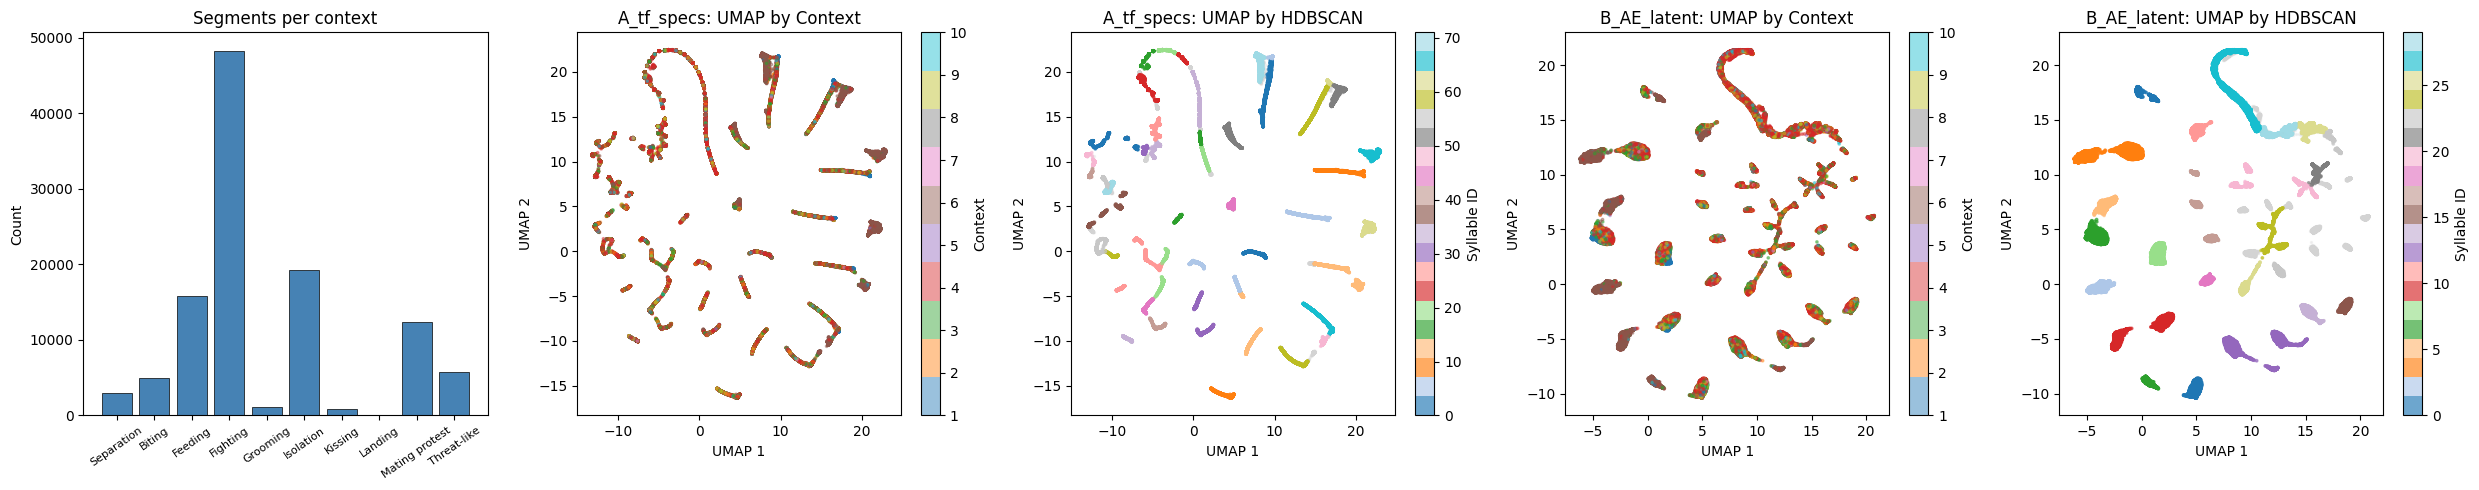

Distinct labels A (incl noise): 73 | excl noise: 72
Distinct labels B (incl noise): 31 | excl noise: 30


In [16]:
plot_branches = [('A_tf_specs', emb_all_A, labels_all_A)]
if emb_all_B is not None:
    plot_branches.append(('B_AE_latent', emb_all_B, labels_all_B))

max_plot = 100_000
if len(seg_df) > max_plot:
    idx_plot = np.random.default_rng(RANDOM_STATE).choice(len(seg_df), size=max_plot, replace=False)
else:
    idx_plot = np.arange(len(seg_df))

seg_plot = seg_df.iloc[idx_plot]

ncols = 1 + 2 * len(plot_branches)
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))

ctx = seg_df['Context'].value_counts().sort_index()
axes[0].bar([CONTEXT_NAMES.get(c, str(c)) for c in ctx.index], ctx.values, color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_title('Segments per context')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35, labelsize=8)

col = 1
for name, emb_all, labels_all in plot_branches:
    emb = emb_all[idx_plot]
    lab = labels_all[idx_plot]

    sc1 = axes[col].scatter(emb[:, 0], emb[:, 1], c=seg_plot['Context'].astype(int).values, s=3, alpha=0.45, cmap='tab10')
    axes[col].set_title(f'{name}: UMAP by Context')
    axes[col].set_xlabel('UMAP 1')
    axes[col].set_ylabel('UMAP 2')
    plt.colorbar(sc1, ax=axes[col], label='Context')

    noise = lab == -1
    axes[col + 1].scatter(emb[noise, 0], emb[noise, 1], c='lightgray', s=2, alpha=0.25)
    sc2 = axes[col + 1].scatter(emb[~noise, 0], emb[~noise, 1], c=lab[~noise], s=3, alpha=0.65, cmap='tab20')
    axes[col + 1].set_title(f'{name}: UMAP by HDBSCAN')
    axes[col + 1].set_xlabel('UMAP 1')
    axes[col + 1].set_ylabel('UMAP 2')
    plt.colorbar(sc2, ax=axes[col + 1], label='Syllable ID')

    col += 2

plt.tight_layout()
plt.show()

print('Distinct labels A (incl noise):', pd.Series(labels_all_A).nunique(), '| excl noise:', pd.Series(labels_all_A[labels_all_A >= 0]).nunique())
if labels_all_B is not None:
    print('Distinct labels B (incl noise):', pd.Series(labels_all_B).nunique(), '| excl noise:', pd.Series(labels_all_B[labels_all_B >= 0]).nunique())


## 11) Set final labels from best branch


In [17]:
if summary_B is None:
    final_branch = 'A_tf_specs'
else:
    final_branch = 'A_tf_specs' if summary_A['selected']['score'] >= summary_B['selected']['score'] else 'B_AE_latent'

if final_branch == 'A_tf_specs':
    seg_df['syllable_id'] = labels_all_A
    embedding_all = emb_all_A
else:
    seg_df['syllable_id'] = labels_all_B
    embedding_all = emb_all_B

print('Final branch:', final_branch)
print('Final distinct labels incl noise:', seg_df['syllable_id'].nunique())
print('Final distinct labels excl noise:', seg_df.loc[seg_df['syllable_id'] >= 0, 'syllable_id'].nunique())


Final branch: A_tf_specs
Final distinct labels incl noise: 73
Final distinct labels excl noise: 72


## 12) Build by-file sequences (ready for HP1/HP2/HP3)


In [18]:
by_file = (
    seg_df.sort_values(['FileName', 'StartSample'])
    .groupby('FileName', sort=False)
    .agg(
        seq=('syllable_id', list),
        context=('Context', lambda x: int(x.mode().iloc[0])),
        emitter=('Emitter', 'first'),
    )
    .reset_index()
)

by_file['seq'] = by_file['seq'].apply(lambda s: [x for x in s if x >= 0])
by_file = by_file[by_file['seq'].apply(len) >= 2].copy()

ctx_counts = by_file['context'].value_counts()
keep_ctx = ctx_counts[ctx_counts >= MIN_SAMPLES_PER_CONTEXT].index
by_file = by_file[by_file['context'].isin(keep_ctx)].copy()

print('Files with >=2 non-noise syllables:', len(by_file))
print('Contexts kept >=%d:' % MIN_SAMPLES_PER_CONTEXT, sorted(by_file['context'].unique().tolist()))
print(by_file['context'].map(CONTEXT_NAMES).value_counts().sort_index())
print('Continue with HP1/HP2/HP3 tests from assom_refined_reproduction.ipynb if needed.')


Files with >=2 non-noise syllables: 16412
Contexts kept >=30: [1, 2, 3, 4, 5, 6, 7, 9, 10]
context
Biting             849
Feeding           3220
Fighting          6002
Grooming           207
Isolation         3543
Kissing            143
Mating protest    1268
Separation         438
Threat-like        742
Name: count, dtype: int64
Continue with HP1/HP2/HP3 tests from assom_refined_reproduction.ipynb if needed.


## Notes

- This notebook compares tf_specs and AE-latent branches using the same selection objective.
- If `vocalseg` is missing, install it; otherwise reproduction quality usually degrades.
